<a href="https://colab.research.google.com/github/lokithasendila/telco-churn-ml/blob/dev/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
print(df.shape)

(7043, 21)


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [7]:
df['Churn'].value_counts() #this counts how many students churned

Churn
No     5174
Yes    1869
Name: count, dtype: int64

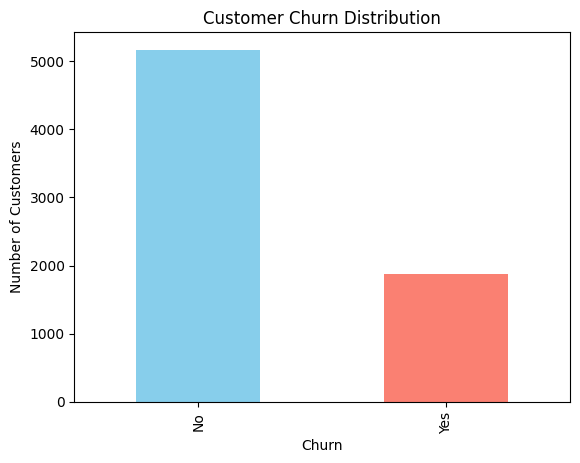

In [8]:
#in this chart the target var is the chain count
import matplotlib.pyplot as plt
df['Churn'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

a model that always predicts "No" would be right 73% of the time simply because 73% of customers don't churn — but it would be useless, since it never catches a single customer who's about to leave.

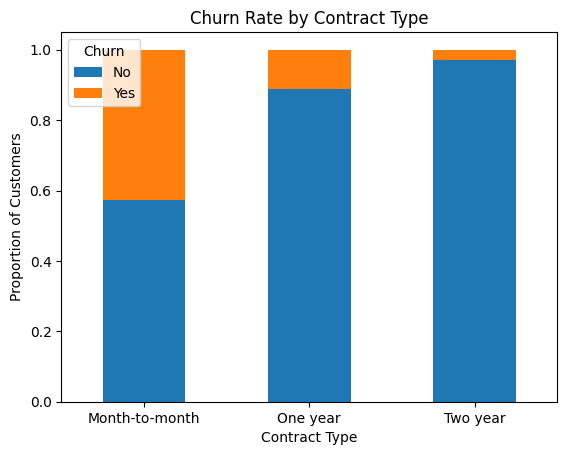

In [9]:
#
import pandas as pd

pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar', stacked=True) #bulid the cross tabularity table 

plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion of Customers')
plt.xlabel('Contract Type')
plt.legend(title='Churn')
plt.xticks(rotation=0)
plt.show()

**Tenure Distribution by Churn**

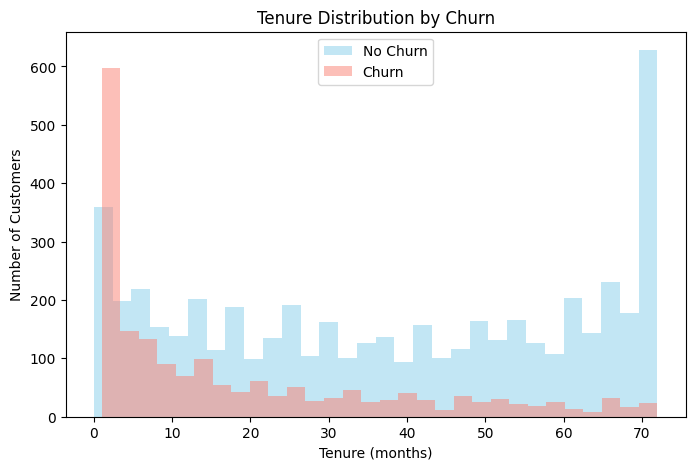

In [10]:
plt.figure(figsize=(8,5)) #set the chart size in inches
plt.hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.5, label='No Churn', color='skyblue') # in the filtering it create the true or false mask
plt.hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.5, label='Churn', color='salmon')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Tenure Distribution by Churn')
plt.legend()
plt.show()

**Monthly Charges by Churn Status**

<Figure size 800x500 with 0 Axes>

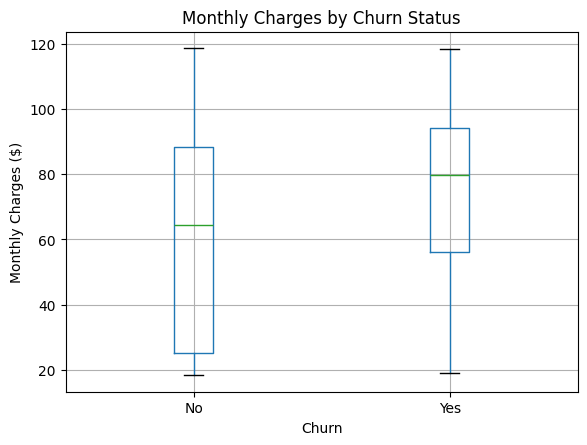

In [11]:
#draws the boxplot to show a distribution's median,spred, outliers and split by the group
plt.figure(figsize=(8,5))
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly Charges by Churn Status')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

**Data Cleaning & Preparation**

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') #fix the totcharges and tries to convert to numeric values if can't then adding NaN
print(df['TotalCharges'].isnull().sum()) #prints the NaN values all

11


**Drop the customerID**

In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(0) #fills evry NaN colmun with 0
print(df['TotalCharges'].isnull().sum())  # prints the NaN values now 

0


In [14]:
df = df.drop('customerID', axis=1) # drop the customer id it is not valuble 

**Encode All Categorical colmuns into numbers**

In [15]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder() #creates an encoder object 
for col in binary_cols: #loops through the each binary column
    df[col] = le.fit_transform(df[col]) #learns the 2 categories andd converts them to 0/1 replace the cloumn

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


**One-Hot Encoding the remaining categorical columns**

In [16]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [17]:
print(df.shape)
df.dtypes

(7043, 31)


gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

In [ ]:
bool_cols = df.select_dtypes(include='bool').columns #convert all bool type for the integers
df[bool_cols] = df[bool_cols].astype(int)
df.dtypes.unique()

array([dtype('int64')], dtype=object)

Train and Test Datas

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Build Models**

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.7473385379701917


In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8069552874378992


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7814052519517388


KNN Hyperparameter tuning

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
grid_knn.fit(X_train_scaled, y_train)

print("Best K:", grid_knn.best_params_)
print("Best CV F1 score:", grid_knn.best_score_)

Best K: {'n_neighbors': 15}
Best CV F1 score: 0.585469071627947


In [25]:
best_knn = grid_knn.best_estimator_
y_pred_knn_tuned = best_knn.predict(X_test_scaled)
print("Tuned KNN Accuracy:", accuracy_score(y_test, y_pred_knn_tuned))

Tuned KNN Accuracy: 0.7707594038325053


Tuned Logistic Regression

In [28]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_scaled, y_train)
print("Best C:", grid_lr.best_params_)
print("Best CV F1:", grid_lr.best_score_)

Best C: {'C': 1}
Best CV F1: 0.5991212216163546


In [29]:
best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_scaled)
print("Tuned LogReg Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))

Tuned LogReg Accuracy: 0.8069552874378992


Tuned Random Forests

In [30]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train_scaled, y_train)

print("Best params:", grid_rf.best_params_)
print("Best CV F1:", grid_rf.best_score_)

Best params: {'max_depth': 10, 'n_estimators': 200}
Best CV F1: 0.5656315261147256


In [31]:
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)
print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

Tuned RF Accuracy: 0.8019872249822569


Compare & evaluate Models properly

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    'KNN': y_pred_knn_tuned,
    'Logistic Regression': y_pred_lr_tuned,
    'Random Forest': y_pred_rf_tuned
}

for name, preds in models.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds, target_names=['No Churn', 'Churn']))


--- KNN ---
              precision    recall  f1-score   support

    No Churn       0.84      0.86      0.85      1035
       Churn       0.57      0.54      0.55       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted 

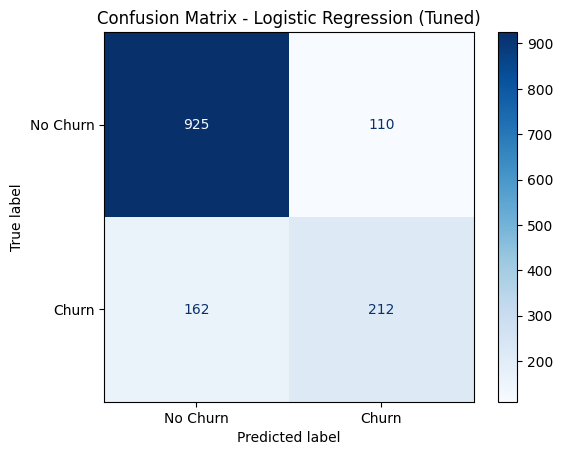

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_tuned, display_labels=['No Churn', 'Churn'], cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Tuned)')
plt.show()